In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


In [51]:
df=pd.read_csv("Data/preprocessed_data.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,y,previous_contacted,previous_success,age_group
0,30,unemployed,married,primary,0,0.282211,0,0,cellular,19,oct,-0.888110,1,-1,0,0,0,0,Young
1,33,services,married,secondary,0,1.209846,1,1,cellular,11,may,0.166967,1,339,4,0,1,0,Adult
2,35,management,single,tertiary,0,0.130429,1,0,cellular,16,apr,-0.023029,1,330,1,0,1,0,Adult
3,30,management,married,tertiary,0,0.174936,1,1,unknown,3,jun,0.056370,4,-1,0,0,0,0,Young
4,59,blue-collar,married,secondary,0,-0.445382,1,0,unknown,5,may,0.196908,1,-1,0,0,0,0,Senior


In [52]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)



Dataset Shape: (4521, 19)

Data Types:

age                     int64
job                       str
marital                   str
education                 str
default                 int64
balance               float64
housing                 int64
loan                    int64
contact                   str
day                     int64
month                     str
duration              float64
campaign                int64
pdays                   int64
previous                int64
y                       int64
previous_contacted      int64
previous_success        int64
age_group                 str
dtype: object


In [53]:
#Basic Data OVERview
print("\nStatistical Summary:\n")
print(df.describe().T)


Statistical Summary:

                     count          mean         std        min        25%  \
age                 4521.0  4.117010e+01   10.576211  19.000000  33.000000   
default             4521.0  1.681044e-02    0.128575   0.000000   0.000000   
balance             4521.0  0.000000e+00    1.000111 -13.487835  -0.397773   
housing             4521.0  5.660252e-01    0.495676   0.000000   0.000000   
loan                4521.0  1.528423e-01    0.359875   0.000000   0.000000   
day                 4521.0  1.591528e+01    8.247667   1.000000   9.000000   
duration            4521.0  2.836827e-16    1.000111  -3.096121  -0.620609   
campaign            4521.0  2.793630e+00    3.109807   1.000000   1.000000   
pdays               4521.0  3.976664e+01  100.121124  -1.000000  -1.000000   
previous            4521.0  5.425791e-01    1.693562   0.000000   0.000000   
y                   4521.0  1.152400e-01    0.319347   0.000000   0.000000   
previous_contacted  4521.0  1.804910e-01 

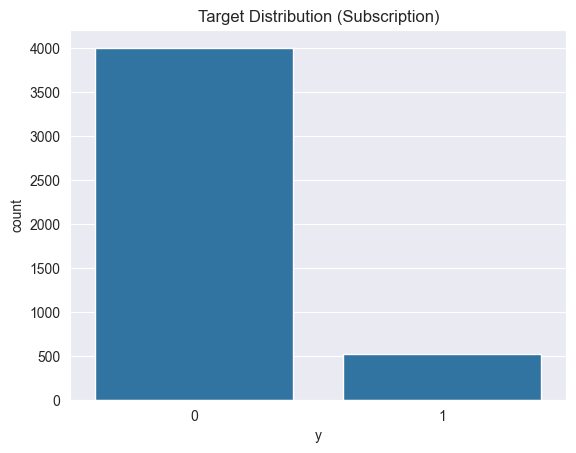

Target Percentage Distribution:

y
0    88.476001
1    11.523999
Name: proportion, dtype: float64


In [54]:
#TARGET VARIABLE ANALYSI
sns.countplot(x='y', data=df)
plt.title("Target Distribution (Subscription)")
plt.show()

print("Target Percentage Distribution:\n")
print(df['y'].value_counts(normalize=True) * 100)


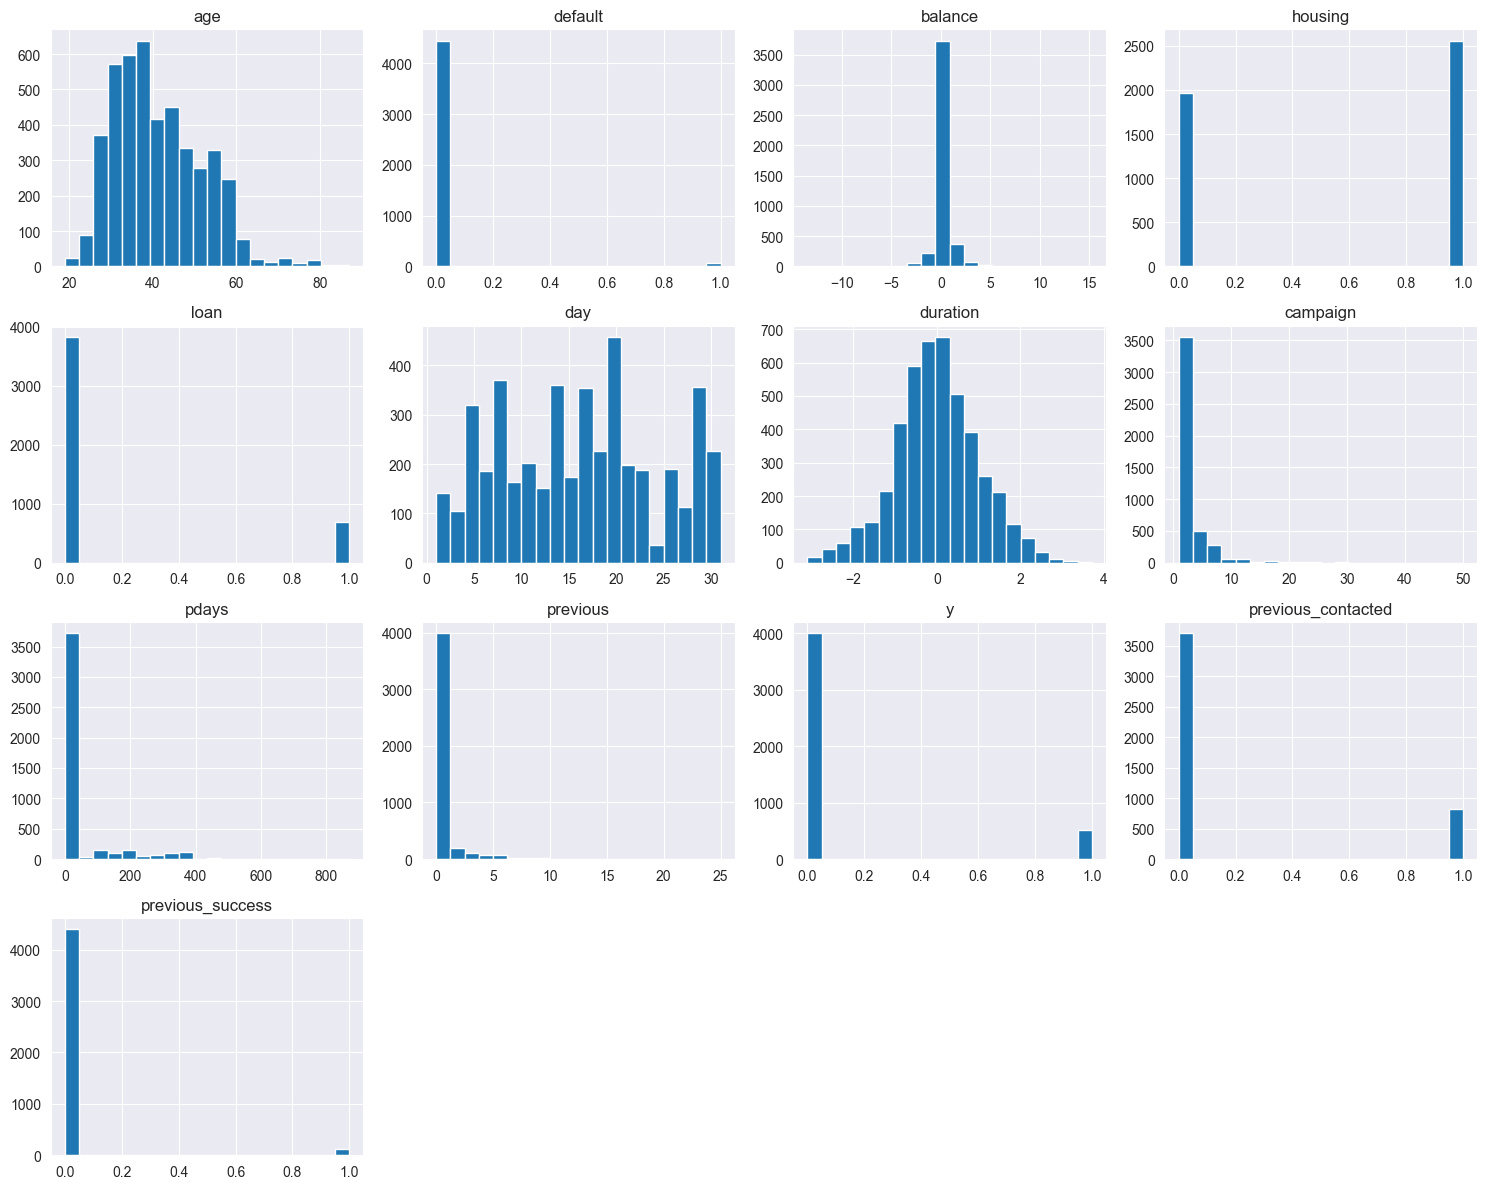

In [55]:
#NUMERICAL FEATURE DISTRIBUTION
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()


In [56]:
#SKEWNESS CHECK
print("Skewness:\n")
print(df[num_cols].skew().sort_values(ascending=False))


Skewness:

default               7.519405
previous              5.875259
previous_success      5.665437
campaign              4.743914
pdays                 2.717071
y                     2.410736
loan                  1.930177
previous_contacted    1.662082
balance               1.580521
age                   0.699501
day                   0.094627
duration              0.012973
housing              -0.266522
dtype: float64


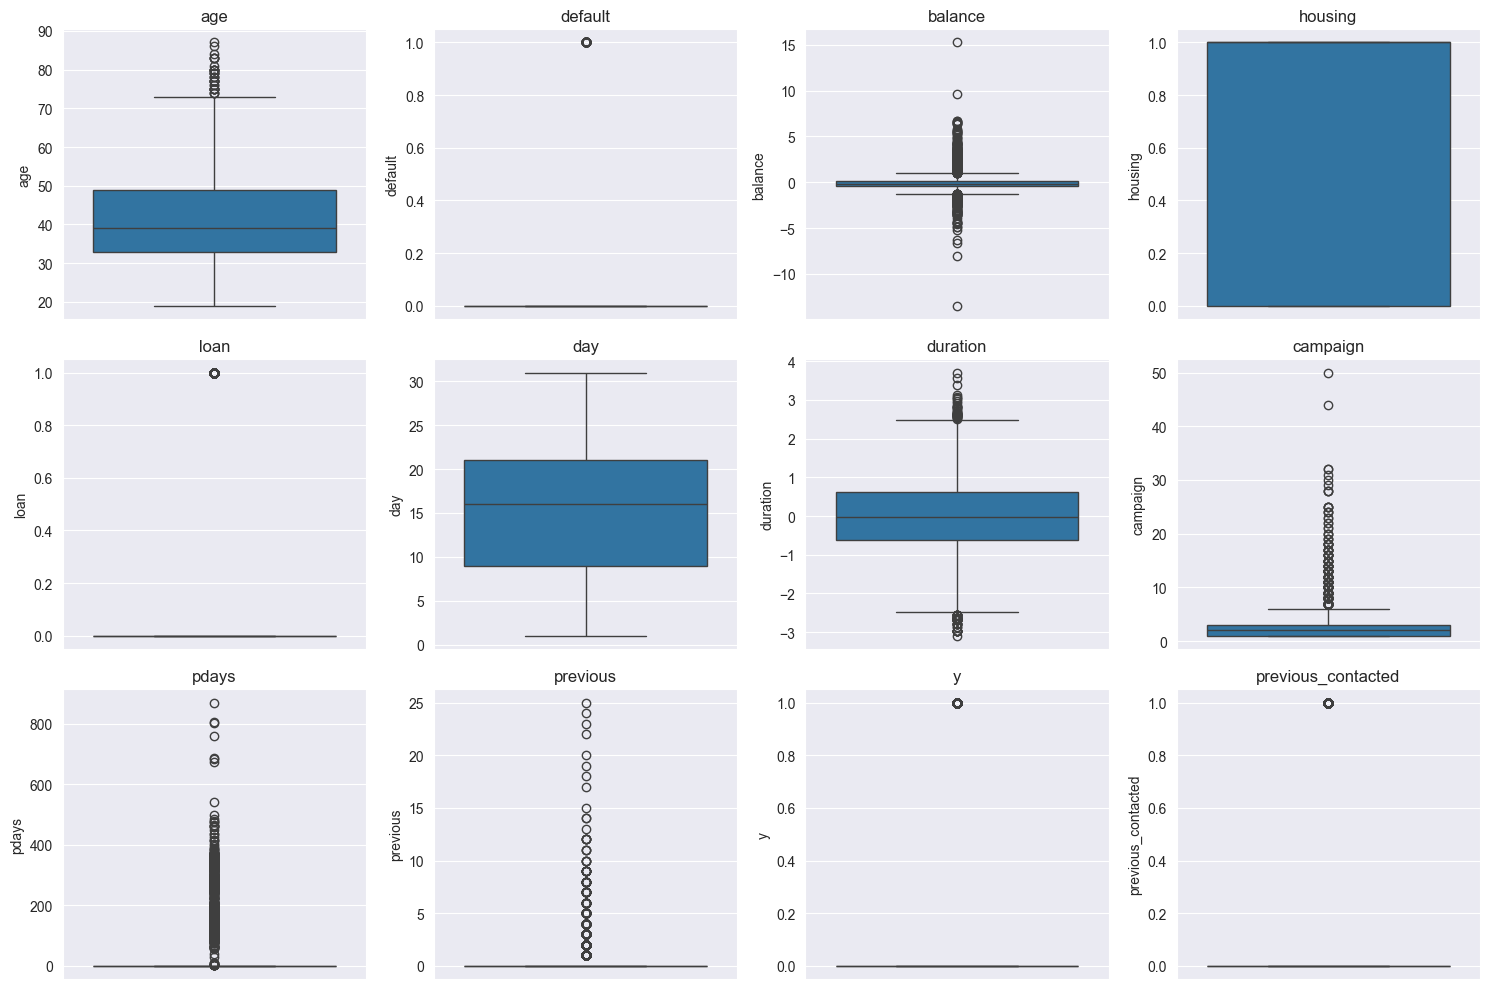

In [57]:
#OUTLIER ANALYSIS (BOXPLOTS)
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols[:-1]):  # exclude target
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


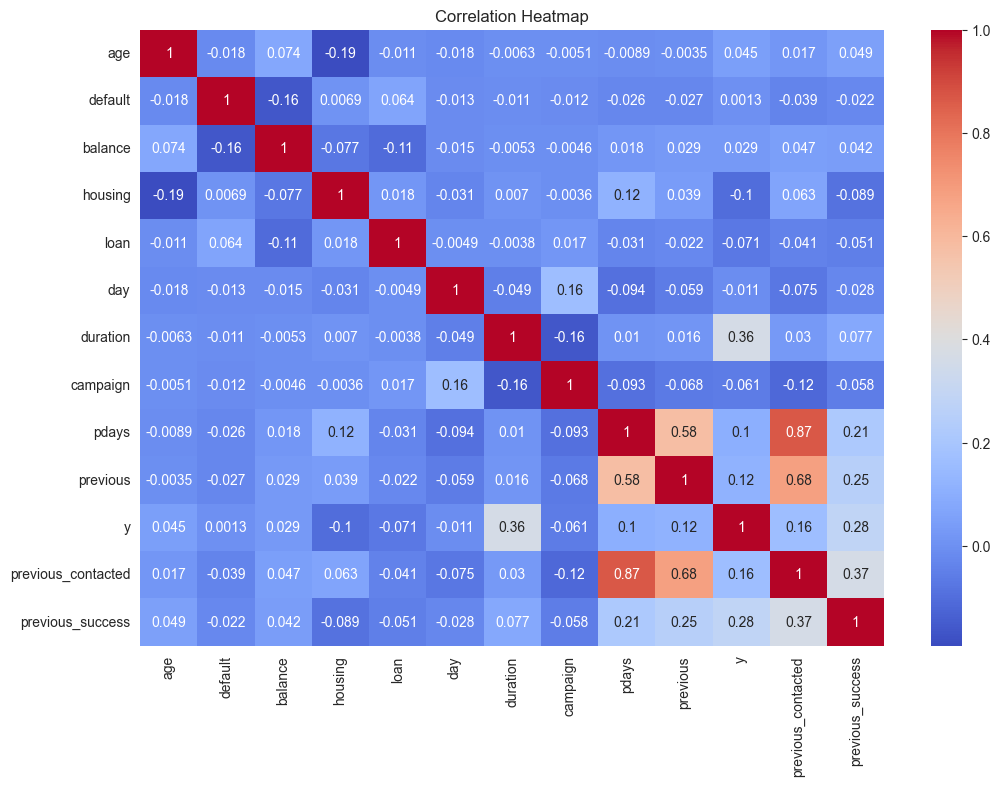

In [58]:
#CORRELATION ANALYSIS
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=True)
plt.title("Correlation Heatmap")
plt.show()


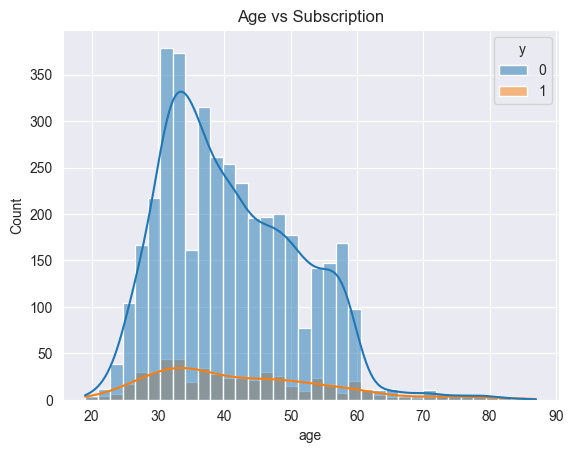

In [59]:
#BIVARIATE ANALYSIS (NUMERIC vs TARGET)
sns.histplot(data=df, x='age', hue='y', kde=True)
plt.title("Age vs Subscription")
plt.show()


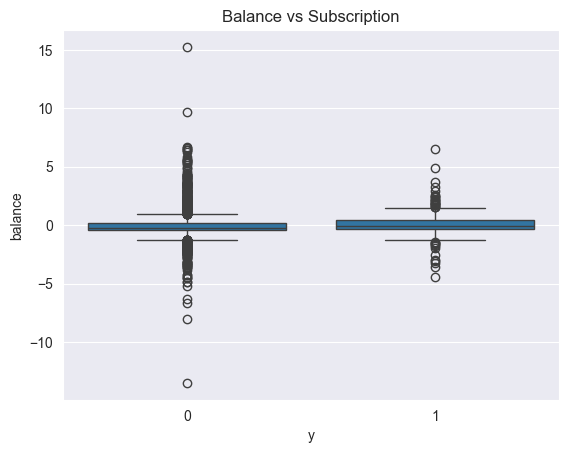

In [60]:
sns.boxplot(x='y', y='balance', data=df)
plt.title("Balance vs Subscription")
plt.show()


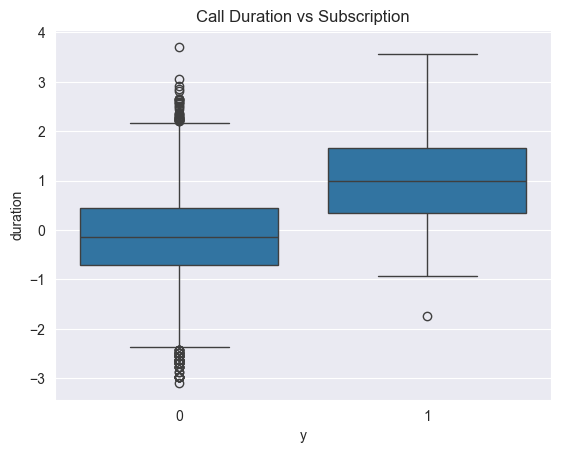

In [61]:
sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration vs Subscription")
plt.show()


In [62]:
#CATEGORICAL FEATURE ANALYSIS
cat_cols = df.select_dtypes(include=['object','category','string']).columns

for col in cat_cols:
    print("\nConversion Rate by", col)
    print(df.groupby(col)['y'].mean().sort_values(ascending=False))



Conversion Rate by job
job
retired          0.234783
student          0.226190
unknown          0.184211
management       0.135191
housemaid        0.125000
admin.           0.121339
self-employed    0.109290
technician       0.108073
unemployed       0.101562
services         0.091127
entrepreneur     0.089286
blue-collar      0.072939
Name: y, dtype: float64

Conversion Rate by marital
marital
divorced    0.145833
single      0.139632
married     0.099035
Name: y, dtype: float64

Conversion Rate by education
education
tertiary     0.142963
secondary    0.106245
unknown      0.101604
primary      0.094395
Name: y, dtype: float64

Conversion Rate by contact
contact
telephone    0.146179
cellular     0.143646
unknown      0.046073
Name: y, dtype: float64

Conversion Rate by month
month
oct    0.462500
dec    0.450000
mar    0.428571
sep    0.326923
apr    0.191126
feb    0.171171
aug    0.124803
jan    0.108108
jun    0.103578
nov    0.100257
jul    0.086402
may    0.066524
Name: y, dt

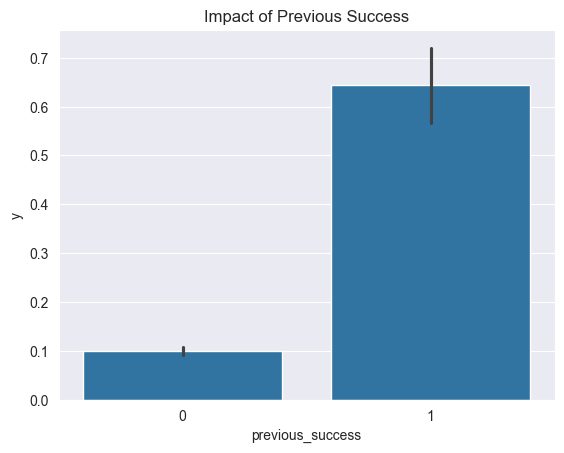

In [63]:
#PREVIOUS CAMPAIGN IMPACT
sns.barplot(x='previous_success', y='y', data=df)
plt.title("Impact of Previous Success")
plt.show()


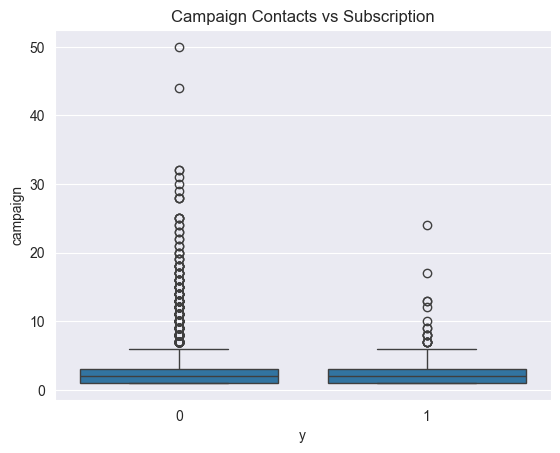

In [64]:
#CAMPAIGN FREQUENCY IMPACT
sns.boxplot(x='y', y='campaign', data=df)
plt.title("Campaign Contacts vs Subscription")
plt.show()


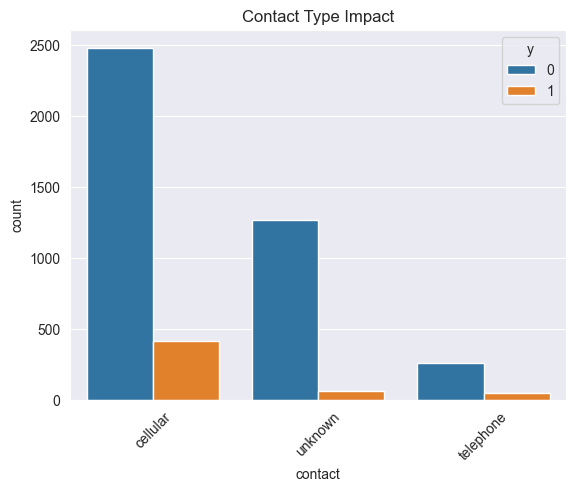

In [65]:
#CONTACT TYPE IMPACT
sns.countplot(x='contact', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Contact Type Impact")
plt.show()


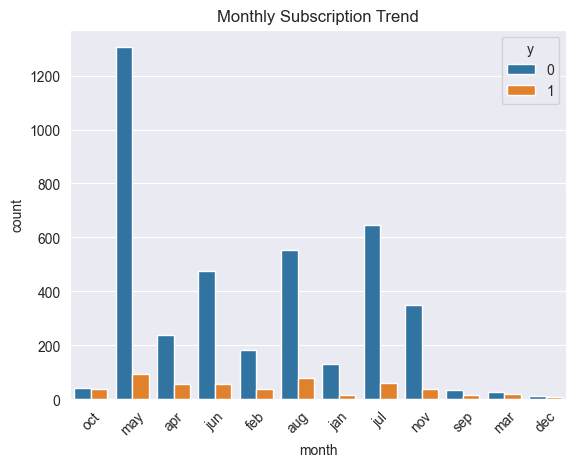

In [66]:
#MONTHLY TREND ANALYSIS
sns.countplot(x='month', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Monthly Subscription Trend")
plt.show()


In [67]:
df.shape


(4521, 19)

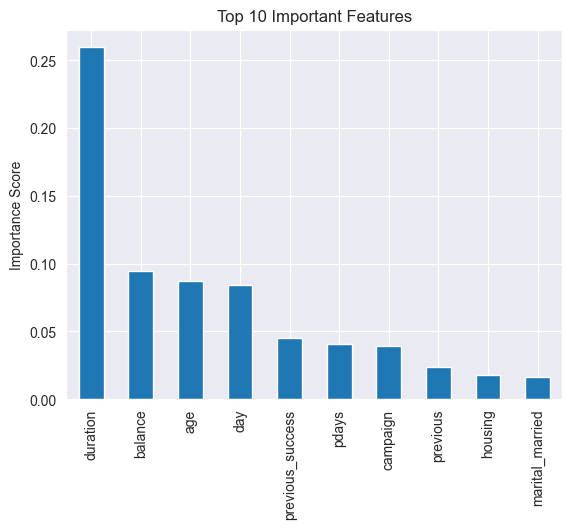

In [68]:
#encoding
df = pd.get_dummies(df, drop_first=True)

# Define X and y
X = df.drop('y', axis=1)
y = df['y']

# Train RandomForest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)


importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

# Plot top 10
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()


In [69]:
df.shape

(4521, 45)